In [3]:
from langchain_chroma import Chroma
from langchain_experimental.open_clip import OpenCLIPEmbeddings


### Ollama 

Tiene 2 clases OllamaLLM y ChatOllama.

* OllamaLLM

You are currently on a page documenting the use of Ollama models as text completion models. Many popular Ollama models are chat completion models.
You may be looking for this page instead.

https://python.langchain.com/docs/integrations/llms/ollama/

* Prueba con texto 

La integracion de ollama con langchain parece que va con texto solo



In [4]:
from langchain_ollama import OllamaLLM

model = OllamaLLM(model="llava:7b")
model.invoke("Come up with 10 names for a song about parrots")

' 1. "Parrot Symphony"\n2. "Macaw Mambo"\n3. "Feathered Friends"\n4. "The Parakeet Polka"\n5. "Cockatoo Cha-Cha"\n6. "Amazon Avenue"\n7. "Lorikeet Lullaby"\n8. "Rainbow Lorikeet Rumba"\n9. "Pionus Peppermint Swing"\n10. "The Parrot\'s Perpetual Motion" '

* Prueba con imagenes


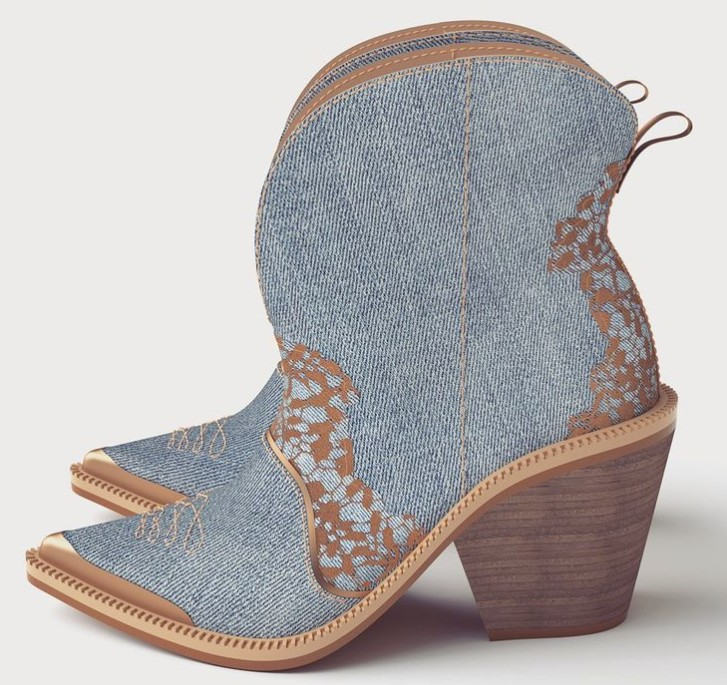

In [5]:
import base64
import io
import os

import numpy as np
from IPython.display import HTML, display
from PIL import Image


def encode_image(image_path):
    """Getting the base64 string"""

    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")


def plt_img_base64(img_base64):
    """Display the base64 image"""

    # Create an HTML img tag with the base64 string as the source
    image_html = f'<img src="data:image/jpeg;base64,{img_base64}" />'

    # Display the image by rendering the HTML
    display(HTML(image_html))


# Image for QA
path = "../datasets_chatbot/images/1.jpg"
# Se convierte la imagen a base64
img_base64 = encode_image(path)
plt_img_base64(img_base64)

In [6]:
from langchain_ollama import OllamaLLM

from langchain_core.messages import HumanMessage, SystemMessage
model = OllamaLLM(model="llava:13b")
response = model.invoke(
    [
        HumanMessage(
            content=[
                {
                    "type": "text",
                    "text": "Describe the image provided in a few words",
                },
                {
                    "type": "image_url",
                    "image_url": {"url": f"data:image/jpeg;base64,{img_base64}"},
                },
            ]
        )
    ]
)

print(response)

 This is a base64-encoded string, which suggests that it could be used to represent an image or other binary data in a text format. Base64 encoding is commonly used for such purposes because it allows binary data to be transmitted over text-based protocols. To decode this string and see the actual content (if any), one would need to use a base64 decoder tool or write a program that can interpret base64 strings.


Se comprueba que la clase OllamaLLM solo funciona con texto, no con imagenes

* ChatOllama

Multi-modal
Ollama has support for multi-modal LLMs, such as bakllava and llava.

ollama pull bakllava

Be sure to update Ollama so that you have the most recent version to support multi-modal.

https://python.langchain.com/docs/integrations/chat/ollama/#multi-modal

* ChatOllama  con texto

In [7]:
from langchain_ollama import ChatOllama

model = ChatOllama(model="llama3.2-vision:11b")
model.invoke("Capital of france?")

AIMessage(content='The capital of France is Paris.', additional_kwargs={}, response_metadata={'model': 'llama3.2-vision:11b', 'created_at': '2025-01-07T17:21:43.0816014Z', 'done': True, 'done_reason': 'stop', 'total_duration': 12886068400, 'load_duration': 11339145700, 'prompt_eval_count': 14, 'prompt_eval_duration': 922000000, 'eval_count': 8, 'eval_duration': 619000000, 'message': Message(role='assistant', content='', images=None, tool_calls=None)}, id='run-9fcf9b3c-94bc-450f-8345-495447a03646-0', usage_metadata={'input_tokens': 14, 'output_tokens': 8, 'total_tokens': 22})

In [8]:
from langchain_ollama import ChatOllama

model = ChatOllama(model="llava:13b")
model.invoke("Capital of france?")

AIMessage(content=' The capital of France is Paris.', additional_kwargs={}, response_metadata={'model': 'llava:13b', 'created_at': '2025-01-07T17:21:50.4584996Z', 'done': True, 'done_reason': 'stop', 'total_duration': 6929812000, 'load_duration': 5237121000, 'prompt_eval_count': 16, 'prompt_eval_duration': 1142000000, 'eval_count': 8, 'eval_duration': 549000000, 'message': Message(role='assistant', content='', images=None, tool_calls=None)}, id='run-21340a2a-81de-418d-97d8-9800696b893c-0', usage_metadata={'input_tokens': 16, 'output_tokens': 8, 'total_tokens': 24})

* ChatOllama con imagenes


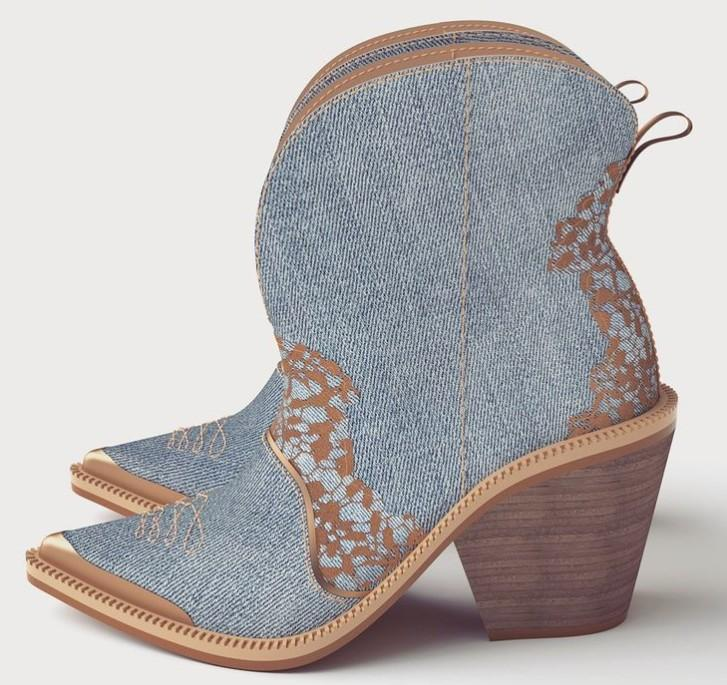

In [9]:
import base64
from io import BytesIO

from IPython.display import HTML, display
from PIL import Image


def convert_to_base64(pil_image):
    """
    Convert PIL images to Base64 encoded strings

    :param pil_image: PIL image
    :return: Re-sized Base64 string
    """

    buffered = BytesIO()
    pil_image.save(buffered, format="JPEG")  # You can change the format if needed
    img_str = base64.b64encode(buffered.getvalue()).decode("utf-8")
    return img_str


def plt_img_base64(img_base64):
    """
    Disply base64 encoded string as image

    :param img_base64:  Base64 string
    """
    # Create an HTML img tag with the base64 string as the source
    image_html = f'<img src="data:image/jpeg;base64,{img_base64}" />'
    # Display the image by rendering the HTML
    display(HTML(image_html))


file_path = "../datasets_chatbot/images/1.jpg"
pil_image = Image.open(file_path)

image_b64 = convert_to_base64(pil_image)
plt_img_base64(image_b64)

In [10]:
from langchain_core.messages import HumanMessage
from langchain_ollama import ChatOllama

llm = ChatOllama(model="llava:13b", temperature=0)


def prompt_func(data):
    text = data["text"]
    image = data["image"]

    image_part = {
        "type": "image_url",
        "image_url": f"data:image/jpeg;base64,{image}",
    }

    content_parts = []

    text_part = {"type": "text", "text": text}

    content_parts.append(image_part)
    content_parts.append(text_part)

    return [HumanMessage(content=content_parts)]


from langchain_core.output_parsers import StrOutputParser

chain = prompt_func | llm | StrOutputParser()

query_chain = chain.invoke(
    {"text": "Describe the image in a few words", "image": image_b64}
)

print(query_chain)

 A pair of blue denim boots with wooden heels.


In [11]:
from langchain_core.messages import HumanMessage
from langchain_ollama import ChatOllama

llm = ChatOllama(model="llava:13b", temperature=0)


def prompt_func(data):
    text = data["text"]
    image = data["image"]

    image_part = {
        "type": "image_url",
        "image_url": f"data:image/jpeg;base64,{image}",
    }

    content_parts = []

    text_part = {"type": "text", "text": text}

    content_parts.append(image_part)
    content_parts.append(text_part)

    return [HumanMessage(content=content_parts)]


from langchain_core.output_parsers import StrOutputParser

chain = prompt_func | llm | StrOutputParser()

query_chain = chain.invoke(
    {"text": "Describe the image", "image": image_b64}
)

print(query_chain)

 The image shows a single boot positioned against a neutral background. The boot is designed with a denim-like fabric upper, featuring a faded blue color that gives it a distressed look. There are decorative elements on the side of the boot, including what appears to be a floral or paisley pattern in a contrasting color, possibly white or light gray. The sole of the boot is made of wood and has a natural finish, which adds an earthy tone to the overall design. The boot's heel is relatively low compared to typical cowboy boots, suggesting it might be more suitable for casual wear rather than riding or dancing. There are no visible texts or logos on the boot that indicate a brand or designer. The style of the image is product photography, designed to showcase the boot's design and features clearly for potential buyers.


* llama 3.2 vision

In [12]:

llm = ChatOllama(model="llama3.2-vision:11b", temperature=0)
chain = prompt_func | llm | StrOutputParser()

query_chain = chain.invoke(
    {"text": "Describe the image", "image": image_b64}
)

print(query_chain)

The image presents a pair of cowboy boots, showcasing their design and features. The purpose of the image is to highlight the details of the boots.

* A pair of cowboy boots:
	+ The boots are positioned in the center of the image.
	+ They have a light-colored leather or suede material.
	+ The boots feature a pointed toe and a low heel.
* The boots are made of denim and lace:
	+ The upper part of the boot is made of denim, giving it a casual and relaxed look.
	+ The laces are woven through eyelets on the side of the boot, adding a touch of elegance to the design.
* They have a high heel:
	+ The heel of the boot is relatively high, making them suitable for formal occasions or events.
	+ The heel is made of a sturdy material, providing support and stability.

Overall, the image showcases a unique pair of cowboy boots that combine traditional materials with modern elements. The use of denim and lace adds a touch of sophistication to the classic design, while the high heel makes them suitab

* OpenCLIPEmbeddings

In [13]:
embeder = OpenCLIPEmbeddings()

c:\Users\emada\miniconda3\envs\ia_mm_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
len(embeder.embed_query("hola"))


1024

In [15]:
len(embeder.embed_image(["../datasets_chatbot/images/1.jpg"]))

1

* Cargar los datos con langchain

In [16]:
IMAGES_DIR = "..\\datasets_chatbot\\images"
image_uris = sorted(
    [
        os.path.join(IMAGES_DIR, image_name)
        for image_name in os.listdir(IMAGES_DIR)
        if image_name.endswith(".jpg")
    ]
)
image_uris

['..\\datasets_chatbot\\images\\1.jpg',
 '..\\datasets_chatbot\\images\\2.jpg',
 '..\\datasets_chatbot\\images\\3.jpg',
 '..\\datasets_chatbot\\images\\4.jpg',
 '..\\datasets_chatbot\\images\\5.jpg']

In [17]:
# Embed images using the OpenCLIPEmbeddings
img_features = embeder.embed_image(image_uris)

In [18]:
print("total image embeddings:", len(img_features))

total image embeddings: 5


In [19]:
TEXT_DIR = "..\\datasets_chatbot\\descriptions"
text_uris = sorted(
    [
        os.path.join(TEXT_DIR, image_name)
        for image_name in os.listdir(TEXT_DIR)
        if image_name.endswith(".txt")
    ]
)
text_uris

['..\\datasets_chatbot\\descriptions\\1.txt',
 '..\\datasets_chatbot\\descriptions\\2.txt',
 '..\\datasets_chatbot\\descriptions\\3.txt',
 '..\\datasets_chatbot\\descriptions\\4.txt',
 '..\\datasets_chatbot\\descriptions\\5.txt']

* Multi Vectore Store

* Paso 1:crear un resumen de las imagenes y obtener la lista de imagenes codificadas en base 64

In [20]:
import base64
import os

from langchain_core.messages import HumanMessage


def encode_image(image_path):
    """Getting the base64 string"""
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")


def image_summarize(img_base64, prompt):
    """Make image summary"""
    chat = ChatOllama(model="llama3.2-vision:11b", temperature=0, max_tokens=1000)

    msg = chat.invoke(
        [
            HumanMessage(
                content=[
                    {"type": "text", "text": prompt},
                    {
                        "type": "image_url",
                        "image_url": {"url": f"data:image/jpeg;base64,{img_base64}"},
                    },
                ]
            )
        ]
    )
    return msg.content


def generate_img_summaries(path):
    """
    Generate summaries and base64 encoded strings for images
    path: Path to list of .jpg files extracted by Unstructured
    """

    # Store base64 encoded images
    img_base64_list = []

    # Store image summaries
    image_summaries = []

    # Prompt
    prompt = """You are an assistant tasked with summarizing images for retrieval. \
    These summaries will be embedded and used to retrieve the raw image. \
    Give a concise summary of the image that is well optimized for retrieval."""

    # Apply to images
    for img_file in sorted(os.listdir(path)):
        if img_file.endswith(".jpg"):
            img_path = os.path.join(path, img_file)
            base64_image = encode_image(img_path)
            img_base64_list.append(base64_image)
            image_summaries.append(image_summarize(base64_image, prompt))

    return img_base64_list, image_summaries


# Image summaries
img_base64_list, image_summaries = generate_img_summaries(IMAGES_DIR)

In [21]:
img_base64_list

['...']

In [22]:
image_summaries

["The image depicts a pair of cowboy boots, showcasing their unique design and features.\n\n* The boots are made of denim material with a light blue color.\n\t+ They have a distinctive stitching pattern on the sides.\n\t+ The stitching is done in a contrasting brown thread that adds to the overall aesthetic appeal of the boots.\n* The boots feature a high heel, which gives them a stylish and sophisticated look.\n\t+ The heel is thick and sturdy, providing good support for the foot.\n\t+ It also adds to the overall height of the boot, making it more noticeable.\n\nOverall, the image presents a detailed view of the cowboy boots' design and features, highlighting their unique blend of style and functionality.",
 'The image features a pair of cowboy boots, showcasing their unique design and craftsmanship.\n\n* The boots are made from denim material with floral embroidery on the sides.\n\t+ The embroidery is intricate and colorful, adding a touch of elegance to the overall design.\n\t+ The 

In [23]:
# Conclusion tenemos las imagenes en base 64 para que el modelo las use y los resumenes de cada imagen

The image presents a pair of sandals, showcasing their design and features.

*   **Sandals**
    *   The sandals are positioned side by side, with one facing upwards and the other downwards.
    *   They have a light purple sole with a textured pattern resembling brickwork or stone.
    *   The straps are made of red leather or faux leather, featuring a crocodile skin texture.
    *   The straps are designed to wrap around the foot, providing support and comfort.
    *   The sandals appear to be made of high-quality materials, suggesting they may be designer or luxury brands.

In summary, the image showcases a pair of stylish and comfortable-looking sandals with a unique design and high-quality materials.



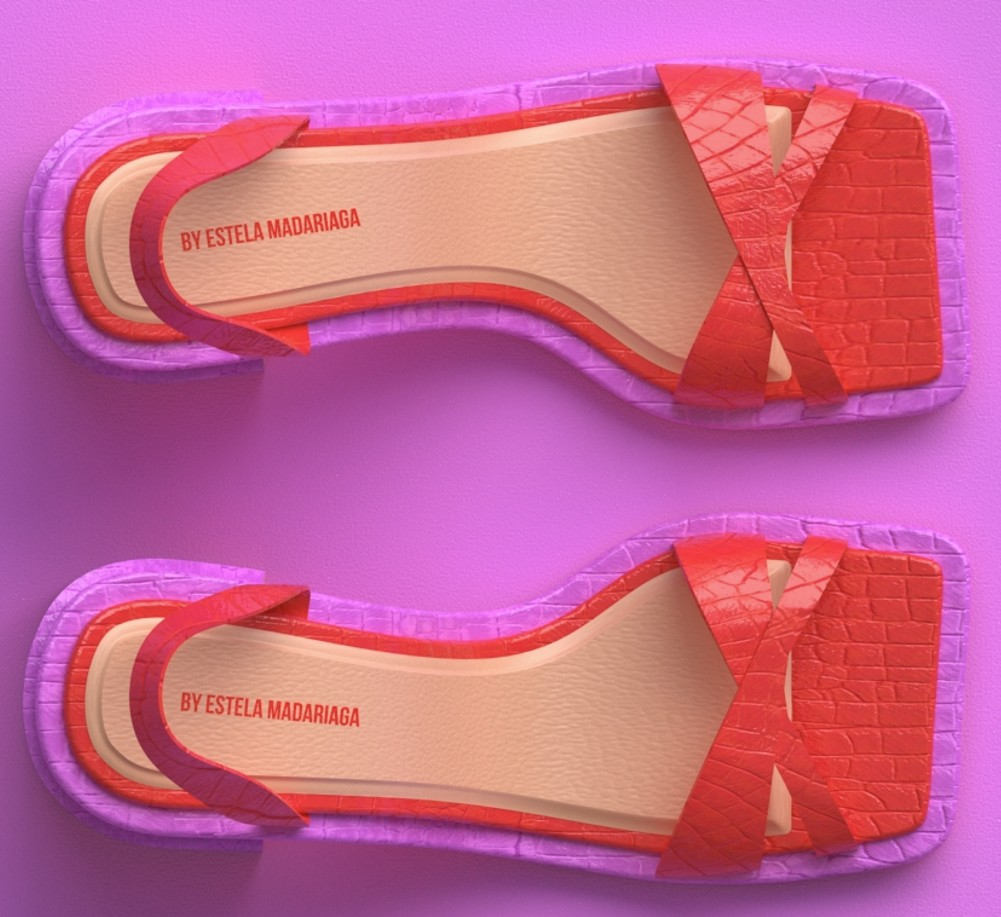

In [24]:
print(image_summaries[3])
plt_img_base64(img_base64_list[3])

* Paso 2: Cargar textos

In [56]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import TextLoader

loader = DirectoryLoader(TEXT_DIR, glob="*.txt", loader_cls=TextLoader)
docs_texts = loader.load()
len(docs_texts)

5

In [57]:
docs_texts

[Document(metadata={'source': '..\\datasets_chatbot\\descriptions\\1.txt'}, page_content='Denim Fabric Cowboy Boots with Camel Floral Embroidery'),
 Document(metadata={'source': '..\\datasets_chatbot\\descriptions\\2.txt'}, page_content='Black Denim Cowboy Boots with Red&Pink Floral Embroidery'),
 Document(metadata={'source': '..\\datasets_chatbot\\descriptions\\3.txt'}, page_content='White & Black Mesh Boot.Estela Madariaga Collection'),
 Document(metadata={'source': '..\\datasets_chatbot\\descriptions\\4.txt'}, page_content='Pink & Red Sandals.Estela Madariaga Collection'),
 Document(metadata={'source': '..\\datasets_chatbot\\descriptions\\5.txt'}, page_content='Peach & White Sneakers.Estela Madariaga Collection')]

In [58]:
texts = [doc.page_content for doc in docs_texts]
text_summaries = texts

In [59]:
texts

['Denim Fabric Cowboy Boots with Camel Floral Embroidery',
 'Black Denim Cowboy Boots with Red&Pink Floral Embroidery',
 'White & Black Mesh Boot.Estela Madariaga Collection',
 'Pink & Red Sandals.Estela Madariaga Collection',
 'Peach & White Sneakers.Estela Madariaga Collection']

In [60]:
text_summaries

['Denim Fabric Cowboy Boots with Camel Floral Embroidery',
 'Black Denim Cowboy Boots with Red&Pink Floral Embroidery',
 'White & Black Mesh Boot.Estela Madariaga Collection',
 'Pink & Red Sandals.Estela Madariaga Collection',
 'Peach & White Sneakers.Estela Madariaga Collection']

Paso 3: 

almacenaremos los resúmenes y sus incrustaciones en una base de datos vectorial

In [85]:
import uuid

from langchain.retrievers.multi_vector import MultiVectorRetriever
from langchain.storage import InMemoryStore
from langchain_chroma import Chroma
from langchain_core.documents import Document

   # Helper function to add documents to the vectorstore and docstore
def add_documents(retriever, doc_summaries, doc_contents):
    id_key = "doc_id"
    doc_ids = [str(uuid.uuid4()) for _ in doc_contents]
    summary_docs = [
        Document(page_content=s, metadata={id_key: doc_ids[i]})
        for i, s in enumerate(doc_summaries)
    ]
    retriever.vectorstore.add_documents(summary_docs)
    retriever.docstore.mset(list(zip(doc_ids, doc_contents)))


def create_multi_vector_retriever(
    vectorstore, image_summaries, images,text_summaries,texts):
    """
    Create retriever that indexes summaries, but returns raw images or texts
    """

    # Initialize the storage layer
    store = InMemoryStore()
    id_key = "doc_id"

    # Create the multi-vector retriever
    retriever = MultiVectorRetriever(
        vectorstore=vectorstore,
        docstore=store,
        id_key=id_key,
    )

    # Add text
    if text_summaries:
        add_documents(retriever, text_summaries, texts)
    # Add images
    if image_summaries:
        add_documents(retriever, image_summaries, images)
    return retriever

* Vector store con chroma

In [86]:
# The vectorstore to use to index the summaries

vectorstore = Chroma(
    collection_name="instagram_images", embedding_function=OpenCLIPEmbeddings(), 
)

In [87]:
# Create retriever
retriever_multi_vector_img = create_multi_vector_retriever(
    vectorstore,
    image_summaries,
    img_base64_list,
    text_summaries,
    texts
)

In [91]:
docs_found = retriever_multi_vector_img.invoke("sandals")
docs_found

['...']


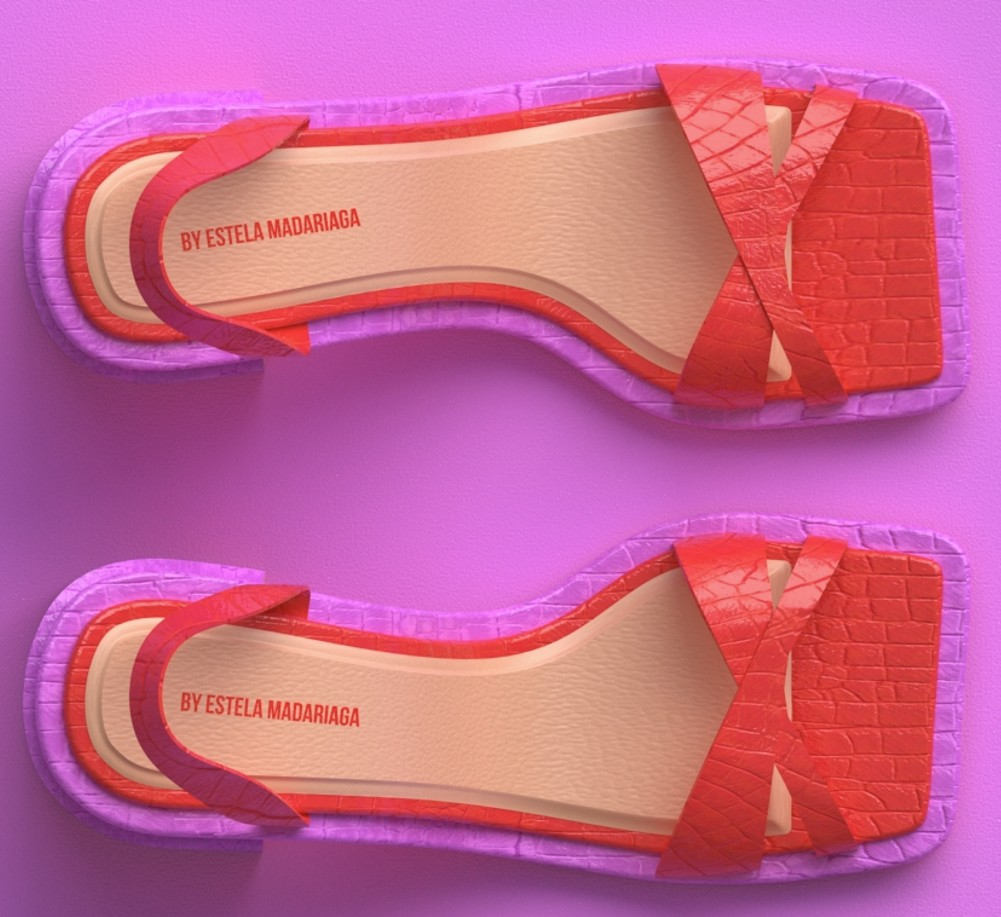

In [92]:
# We get back relevant images
plt_img_base64(docs_found[0])

In [104]:
docs_found = retriever_multi_vector_img.invoke("boots")
docs_found

['...']


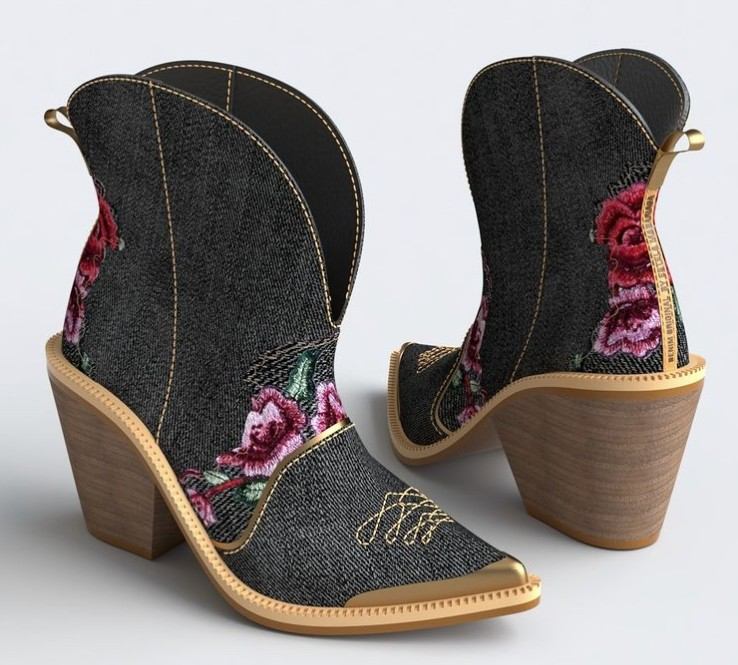

In [105]:
# We get back relevant images
plt_img_base64(docs_found[0])

* Build RAG

In [74]:
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_core.prompts import PromptTemplate

import io
import re

from IPython.display import HTML, display
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from PIL import Image


def plt_img_base64(img_base64):
    """Disply base64 encoded string as image"""
    # Create an HTML img tag with the base64 string as the source
    image_html = f'<img src="data:image/jpeg;base64,{img_base64}" />'
    # Display the image by rendering the HTML
    display(HTML(image_html))


def looks_like_base64(sb):
    """Check if the string looks like base64"""
    return re.match("^[A-Za-z0-9+/]+[=]{0,2}$", sb) is not None


def is_image_data(b64data):
    """
    Check if the base64 data is an image by looking at the start of the data
    """
    image_signatures = {
        b"\xff\xd8\xff": "jpg",
        b"\x89\x50\x4e\x47\x0d\x0a\x1a\x0a": "png",
        b"\x47\x49\x46\x38": "gif",
        b"\x52\x49\x46\x46": "webp",
    }
    try:
        header = base64.b64decode(b64data)[:8]  # Decode and get the first 8 bytes
        for sig, format in image_signatures.items():
            if header.startswith(sig):
                return True
        return False
    except Exception:
        return False


def resize_base64_image(base64_string, size=(128, 128)):
    """
    Resize an image encoded as a Base64 string
    """
    # Decode the Base64 string
    img_data = base64.b64decode(base64_string)
    img = Image.open(io.BytesIO(img_data))

    # Resize the image
    resized_img = img.resize(size, Image.LANCZOS)

    # Save the resized image to a bytes buffer
    buffered = io.BytesIO()
    resized_img.save(buffered, format=img.format)

    # Encode the resized image to Base64
    return base64.b64encode(buffered.getvalue()).decode("utf-8")


def split_image_text_types(docs):
    """
    Split base64-encoded images and texts
    """
    b64_images = []
    texts = []
    for doc in docs:
        # Check if the document is of type Document and extract page_content if so
        if isinstance(doc, Document):
            doc = doc.page_content
        if looks_like_base64(doc) and is_image_data(doc):
            doc = resize_base64_image(doc, size=(1300, 600))
            b64_images.append(doc)
        else:
            texts.append(doc)
    return {"images": b64_images, "texts": texts}


def img_prompt_func(data_dict):
    """
    Join the context into a single string
    """
    formatted_texts = "\n".join(data_dict["context"]["texts"])
    messages = []

    # Adding image(s) to the messages if present
    if data_dict["context"]["images"]:
        for image in data_dict["context"]["images"]:
            image_message = {
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{image}"},
            }
            messages.append(image_message)

    # Adding the text for analysis
    text_message = {
        "type": "text",
        "text": (
            "You are fashion assistant for helping users to find products based on their questions.\n"
            "You will be given a mixed of text, and image(s) usually of shoes.\n"
            "If you don't know the answer, just say that you don't know.\n"
            f"User-provided question: {data_dict['question']}\n\n"
            "Text and / or tables:\n"
            f"{formatted_texts}"
        ),
    }
    messages.append(text_message)
    return [HumanMessage(content=messages)]



def multi_modal_rag_chain(retriever):
    """
    Multi-modal RAG chain
    """

    # Multi-modal LLM
    model =ChatOllama(model="llava:13b", temperature=0, max_tokens=1000)

    # RAG pipeline
    chain = (
        {
            "context": retriever | RunnableLambda(split_image_text_types),
            "question": RunnablePassthrough(),
        }
        | RunnableLambda(img_prompt_func)
        | model
        | StrOutputParser()
    )

    return chain


# Create RAG chain
chain_multimodal_rag = multi_modal_rag_chain(retriever_multi_vector_img)

In [75]:
query = "I'd like to find sandals"
docs_found =  chain_multimodal_rag.invoke(query)



In [76]:
from pprint import pprint
pprint(docs_found)

(' Based on your request for sandals, here are a few options that might '
 'interest you:\n'
 '\n'
 '1. These high heel sandals have a floral pattern and are available in black '
 'and gold colors. They feature an open-toe design and appear to be made of '
 'leather or a similar material.\n'
 '2. This pair of sandals has a unique design with a strap over the foot, '
 'providing additional support. The straps are adorned with red flowers, '
 'adding a touch of color to the otherwise neutral tones.\n'
 '3. These sandals have a chunky heel and a wide strap that wraps around the '
 'ankle for added stability. They come in black and gold colors, similar to '
 'the first pair.\n'
 '4. This pair of sandals has a more traditional design with a single strap '
 'over the foot. The straps are embellished with red flowers, matching the '
 'second pair. These sandals are available in black and gold colors as well.\n'
 '\n'
 'Please let me know if you have any specific preferences or questions about

* Variacion

In [ ]:

def multi_modal_rag_chain(retriever, question,model_name="llama3.2-vision:11b"):
    """
    Multi-modal RAG chain
    """

    # Multi-modal LLM
    model =ChatOllama(model=model_name, temperature=0, max_tokens=1000)

    context = retriever.invoke(question)

    #context = split_image_text_types(context)
    # RAG pipeline
    chain = (
        {
            "context": RunnablePassthrough(),
            "question": RunnablePassthrough(),
        }
        | RunnableLambda(img_prompt_func)
        | model
        | StrOutputParser()
    )
    response = chain.invoke({"context": context, "question": question})
    return response